# **Step 1: Setting Up Google Colab and Installing Required Libraries**

# **1.1 Install Required Libraries**

In [ ]:
!pip install tensorflow numpy pandas matplotlib seaborn opencv-python scikit-learn

# **1.2 Import Required Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil
import cv2
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout, MaxPooling2D, BatchNormalization
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# **1.3 Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Verify the directory structure**

In [ ]:
!ls "/content/drive/MyDrive/Breast Cancer Detection using Deep Learning/Dataset"

BreaKHis_v1  Cancer  Folds.csv


# **Step 2: Preprocessing the Dataset**

# **2.1 Load Folds.csv**

In [ ]:
# Define the CSV file path
csv_path = "/content/drive/MyDrive/Breast Cancer Detection using Deep Learning/Dataset/Folds.csv"

# Load the CSV file
fold_df = pd.read_csv(csv_path)

# Rename the filename column to 'path'
fold_df = fold_df.rename(columns={"filename": "path"})

# Display first few rows
print(fold_df.head(3))

   fold  mag    grp                                               path
0     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...
1     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...
2     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...


# **2.2 Extract Filenames and Labels**

In [ ]:
# Extract filename and label from path
fold_df["filename"] = fold_df["path"].apply(lambda x: x.split("/")[-1])
fold_df["label"] = fold_df["path"].apply(lambda x: x.split("/")[3])  # 3rd index is 'benign' or 'malignant'

# Display modified DataFrame
print(fold_df.head(3))

   fold  mag    grp                                               path  \
0     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...   
1     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...   
2     1  100  train  BreaKHis_v1/histology_slides/breast/benign/SOB...   

                         filename   label  
0  SOB_B_A-14-22549AB-100-001.png  benign  
1  SOB_B_A-14-22549AB-100-002.png  benign  
2  SOB_B_A-14-22549AB-100-003.png  benign  


# **2.3 Move Images to a Common Folder (Cancer)**

In [ ]:
# # Define new directory
cancer_dir = "/content/drive/MyDrive/Breast Cancer Detection using Deep Learning/Dataset/Cancer"
# os.makedirs(cancer_dir, exist_ok=True)  # Create if not exists

# # Move images into 'Cancer' directory
# for p in fold_df['path']:
#     src = f"/content/drive/MyDrive/Breast Cancer Detection using Deep Learning/Dataset/BreaKHis_v1/{p}"
#     dest = os.path.join(cancer_dir, p.split("/")[3] + "_" + p.split("/")[-1])  # Rename as label_filename
#     shutil.copyfile(src, dest)

# Verify count
print(f"Total images moved: {len(os.listdir(cancer_dir))}")

Total images moved: 7609


# **2.4 Verify the New Structure**

In [ ]:
!ls "/content/drive/MyDrive/Breast Cancer Detection using Deep Learning/Dataset/Cancer" | head -10

benign_SOB_B_A-14-22549AB-100-001.png
benign_SOB_B_A-14-22549AB-100-002.png
benign_SOB_B_A-14-22549AB-100-003.png
benign_SOB_B_A-14-22549AB-100-004.png
benign_SOB_B_A-14-22549AB-100-005.png
benign_SOB_B_A-14-22549AB-100-006.png
benign_SOB_B_A-14-22549AB-100-007.png
benign_SOB_B_A-14-22549AB-100-008.png
benign_SOB_B_A-14-22549AB-100-009.png
benign_SOB_B_A-14-22549AB-100-010.png


# **2.5 Visualizing Class Distribution**

<ipython-input-9-a6903f1435a2>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=fold_df['label'], palette="pastel")


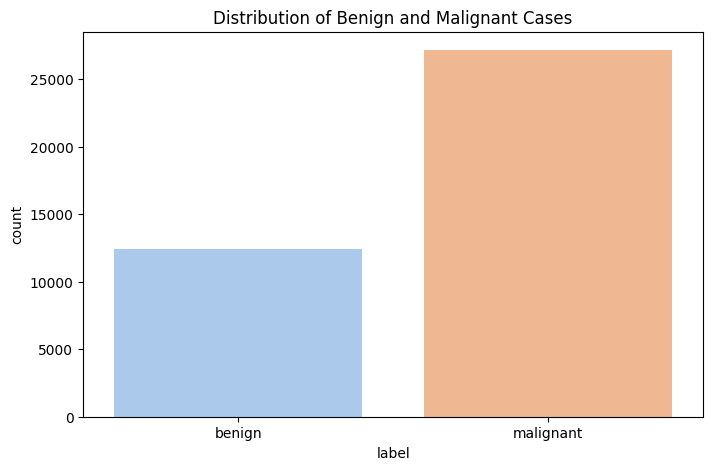

In [ ]:
# Count the number of images per class
plt.figure(figsize=(8,5))
sns.countplot(x=fold_df['label'], palette="pastel")
plt.title("Distribution of Benign and Malignant Cases")
plt.show()

# **Step 3: Splitting the Dataset (Train, Validation, Test)**

# **3.1 Create a New DataFrame for Processed Images**

In [ ]:
# Define the new dataset path
cancer_dir = "/content/drive/MyDrive/Breast Cancer Detection using Deep Learning/Dataset/Cancer"

# Create a DataFrame with file locations and labels
df = pd.DataFrame(os.listdir(cancer_dir), columns=["file_loc"])
df['label'] = df['file_loc'].apply(lambda x: x.split("_")[0])  # Extract 'benign' or 'malignant'
df['class'] = df['label'].apply(lambda x: 0 if x == 'benign' else 1)  # Encode labels

# Set filename as index
df.set_index("file_loc", inplace=True)

# Display the first few rows
print(df.head(5))

                                             label  class
file_loc                                                 
malignant_SOB_M_DC-14-20629-100-002.png  malignant      1
malignant_SOB_M_DC-14-20629-100-003.png  malignant      1
malignant_SOB_M_DC-14-20629-100-004.png  malignant      1
malignant_SOB_M_DC-14-20629-100-005.png  malignant      1
malignant_SOB_M_DC-14-20629-100-006.png  malignant      1


# **3.2 Perform Train-Validation-Test Split**

In [ ]:
# Split dataset into 80% train, 10% validation, and 10% test
data_train_and_val, data_test = train_test_split(df, test_size=0.1, random_state=42, stratify=df['class'])
data_train, data_val = train_test_split(data_train_and_val, test_size=0.1, random_state=42, stratify=data_train_and_val['class'])

# Print dataset sizes
print("Training set size:", data_train.shape)
print("Validation set size:", data_val.shape)
print("Testing set size:", data_test.shape)

Training set size: (6163, 2)
Validation set size: (685, 2)
Testing set size: (761, 2)


# **3.3 Visualize the Data Distribution**

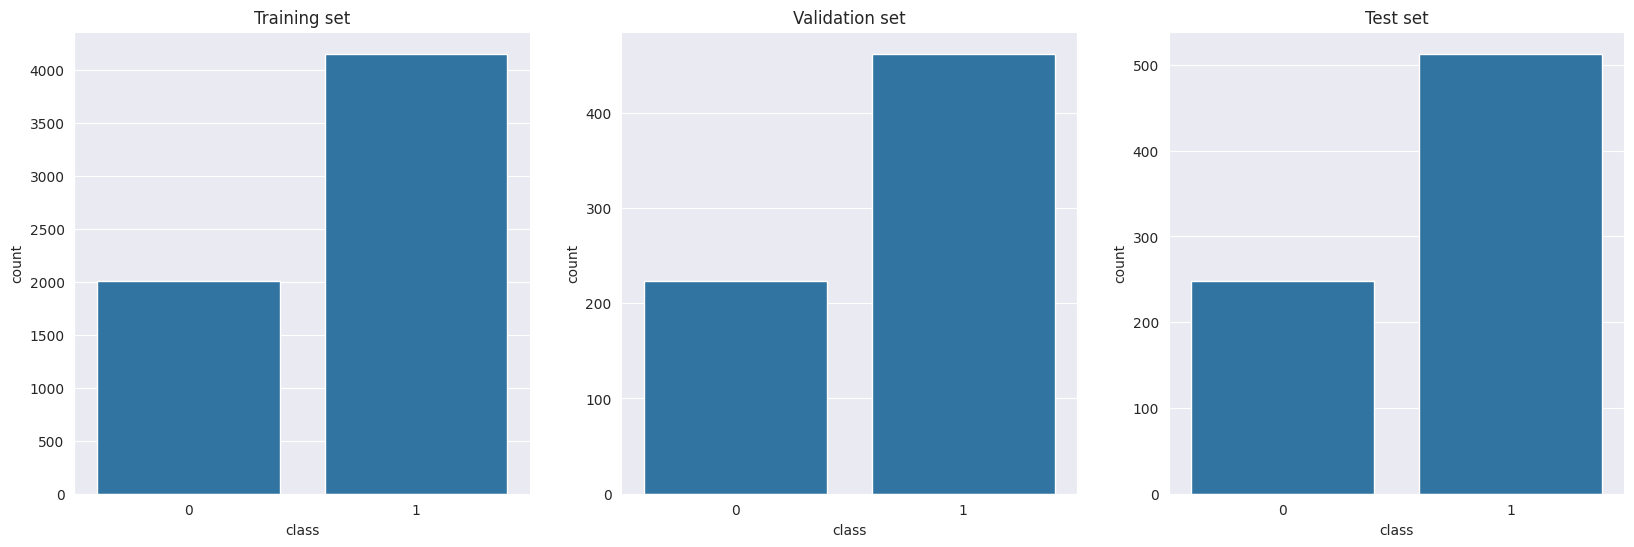

In [ ]:
sns.set_style("darkgrid")
plt.figure(figsize=(20,6))
plt.subplot(1,3,1)
sns.countplot(x=data_train['class'])
plt.title("Training set")
plt.subplot(1,3,2)
sns.countplot(x=data_val['class'])
plt.title("Validation set")
plt.subplot(1,3,3)
sns.countplot(x=data_test['class'])
plt.title("Test set")
plt.show()

# **3.4 Balance the Dataset (Optional)**

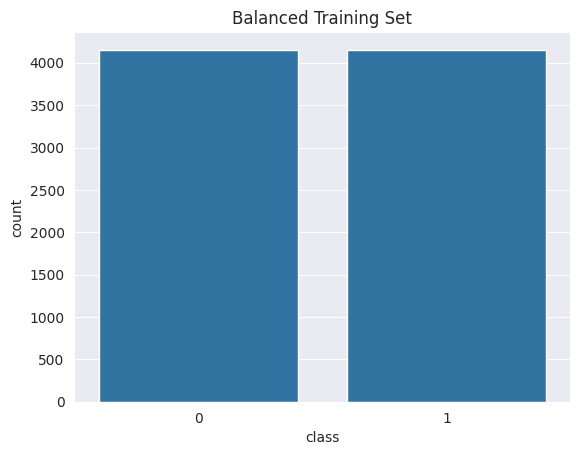

In [ ]:
from sklearn.utils import resample

# Separate benign and malignant cases in training data
train_has_cancer = data_train[data_train['class'] == 1]
train_has_no_cancer = data_train[data_train['class'] == 0]

# Upsample the minority class
train_has_no_cancer_upsample = resample(train_has_no_cancer,
                                        n_samples=len(train_has_cancer),
                                        random_state=42,
                                        replace=True)

# Concatenate the upsampled benign cases with the malignant cases
data_train_balanced = pd.concat([train_has_cancer, train_has_no_cancer_upsample])

# Plot balanced training set
sns.countplot(x=data_train_balanced['class'])
plt.title("Balanced Training Set")
plt.show()

# **Step 4: Image Preprocessing & Data Augmentation**

# **4.1 Define Image Size and Batch Size**

In [ ]:
# Image size and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# **4.2 Create Image Data Generators**

In [ ]:
# Define training image generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,  # Normalize pixel values
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

# Define validation & test image generator (only rescaling)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# **4.3 Create Data Loaders**

In [ ]:
# Convert class labels to string type
data_train_balanced["class"] = data_train_balanced["class"].astype(str)
data_val["class"] = data_val["class"].astype(str)
data_test["class"] = data_test["class"].astype(str)

In [ ]:
# Define dataset directory
cancer_dir = "/content/drive/MyDrive/Breast Cancer Detection using Deep Learning/Dataset/Cancer"

# Ensure 'file_loc' is a column in your DataFrame
data_train_balanced.reset_index(inplace=True) # This adds the index as a column named 'file_loc'
data_val.reset_index(inplace=True)
data_test.reset_index(inplace=True)

# Load training data
train_generator = train_datagen.flow_from_dataframe(
    dataframe=data_train_balanced,
    directory=cancer_dir,
    x_col="file_loc",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"  # Now it will work correctly
)

# Load validation data
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=data_val,
    directory=cancer_dir,
    x_col="file_loc",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

# Load test data
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=data_test,
    directory=cancer_dir,
    x_col="file_loc",
    y_col="class",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 8308 validated image filenames belonging to 2 classes.
Found 685 validated image filenames belonging to 2 classes.
Found 761 validated image filenames belonging to 2 classes.


# **4.4 Visualize Augmented Images**

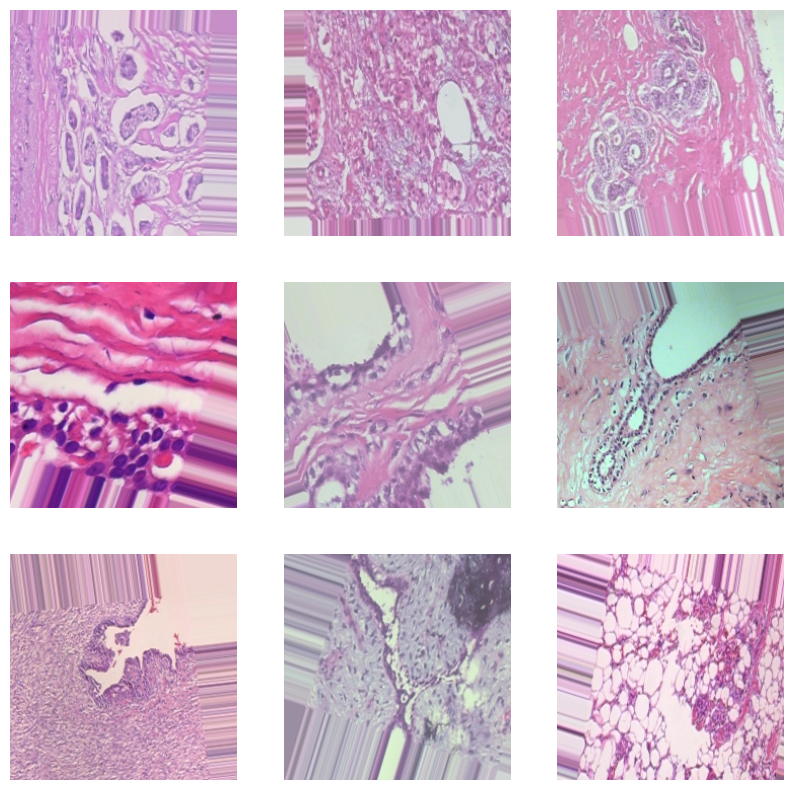

In [ ]:
# Get a batch of training images
sample_images, sample_labels = next(train_generator)

# Plot sample images
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(sample_images[i])
    plt.axis("off")
plt.show()

# **Step 5: Building the CNN Model**

# **Transfer Learning (Pretrained Model)**

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

# Load pre-trained VGG16 without the top layers
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224,224,3))

# Freeze pre-trained layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
x = Dense(1, activation="sigmoid")(x)

# Define new model
model = Model(inputs=base_model.input, outputs=x)

# Display model architecture
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 512)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          65,6

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

# **5.3 Compile the Model**

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# **Step 6: Training the CNN Model**

# **6.1 Define Callbacks**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Early stopping (stops training if validation loss doesn't improve for 5 epochs)
early_stopping = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

# Model checkpoint (saves the best model)
model_checkpoint = ModelCheckpoint("/content/drive/MyDrive/Breast Cancer Detection using Deep Learning/Models/best_model.h5", save_best_only=True, monitor="val_loss", mode="min")

# **6.2 Train the Model**

In [ ]:
# Train the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,  # You can increase if needed
    callbacks=[early_stopping, model_checkpoint]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 989ms/step - accuracy: 0.5931 - loss: 0.6712

260/260 ━━━━━━━━━━━━━━━━━━━━ 692s 1s/step - accuracy: 0.5933 - loss: 0.6710 - val_accuracy: 0.7270 - val_loss: 0.5677
Epoch 2/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 908ms/step - accuracy: 0.7239 - loss: 0.5519

260/260 ━━━━━━━━━━━━━━━━━━━━ 302s 966ms/step - accuracy: 0.7240 - loss: 0.5518 - val_accuracy: 0.7898 - val_loss: 0.4461
Epoch 3/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 889ms/step - accuracy: 0.7714 - loss: 0.4882

260/260 ━━━━━━━━━━━━━━━━━━━━ 245s 939ms/step - accuracy: 0.7714 - loss: 0.4882 - val_accuracy: 0.8146 - val_loss: 0.4008
Epoch 4/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 878ms/step - accuracy: 0.7764 - loss: 0.4697

...

260/260 ━━━━━━━━━━━━━━━━━━━━ 254s 978ms/step - accuracy: 0.8254 - loss: 0.3962 - val_accuracy: 0.8496 - val_loss: 0.3438
Epoch 10/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 243s 933ms/step - accuracy: 0.8274 - loss: 0.3828 - val_accuracy: 0.8584 - val_loss: 0.3477
Epoch 11/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 892ms/step - accuracy: 0.8261 - loss: 0.3881

260/260 ━━━━━━━━━━━━━━━━━━━━ 245s 942ms/step - accuracy: 0.8261 - loss: 0.3881 - val_accuracy: 0.8555 - val_loss: 0.3317
Epoch 12/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 242s 928ms/step - accuracy: 0.8316 - loss: 0.3806 - val_accuracy: 0.8613 - val_loss: 0.3318
Epoch 13/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 241s 927ms/step - accuracy: 0.8350 - loss: 0.3775 - val_accuracy: 0.8672 - val_loss: 0.3317
Epoch 14/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 869ms/step - accuracy: 0.8417 - loss: 0.3727

260/260 ━━━━━━━━━━━━━━━━━━━━ 239s 919ms/step - accuracy: 0.8417 - loss: 0.3727 - val_accuracy: 0.8540 - val_loss: 0.3205
Epoch 15/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 260s 912ms/step - accuracy: 0.8379 - loss: 0.3694 - val_accuracy: 0.8511 - val_loss: 0.3725
Epoch 16/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 865ms/step - accuracy: 0.8431 - loss: 0.3598

260/260 ━━━━━━━━━━━━━━━━━━━━ 238s 915ms/step - accuracy: 0.8430 - loss: 0.3598 - val_accuracy: 0.8774 - val_loss: 0.3138
Epoch 17/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 235s 903ms/step - accuracy: 0.8432 - loss: 0.3506 - val_accuracy: 0.8642 - val_loss: 0.3477
Epoch 18/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 235s 904ms/step - accuracy: 0.8350 - loss: 0.3667 - val_accuracy: 0.8628 - val_loss: 0.3520
Epoch 19/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 859ms/step - accuracy: 0.8444 - loss: 0.3626

260/260 ━━━━━━━━━━━━━━━━━━━━ 236s 908ms/step - accuracy: 0.8445 - loss: 0.3626 - val_accuracy: 0.8803 - val_loss: 0.3028
Epoch 20/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 238s 916ms/step - accuracy: 0.8503 - loss: 0.3443 - val_accuracy: 0.8759 - val_loss: 0.3068


# **6.3 Plot Training Performance**

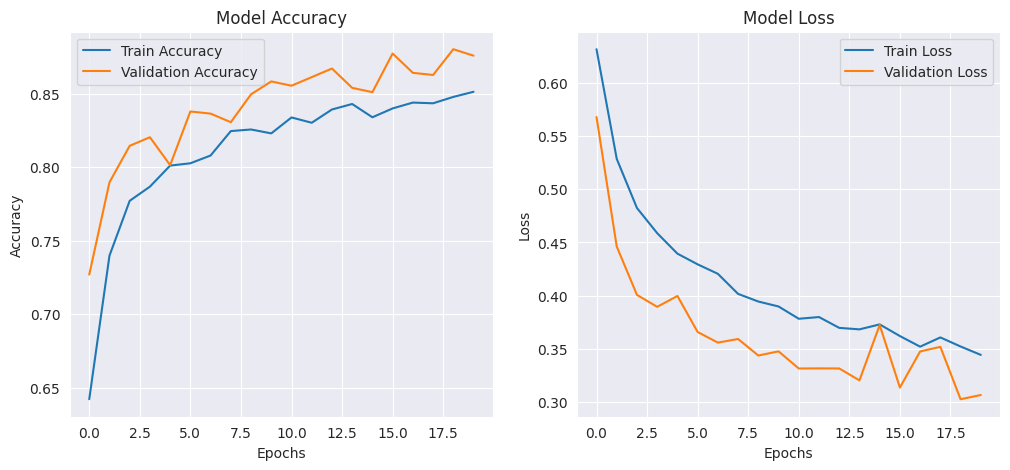

In [ ]:
# Plot training history
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Accuracy")

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Model Loss")

plt.show()

# **Step 7: Model Evaluation**

# **7.1 Evaluate the Model**

In [ ]:
# Load the best saved model
best_model = load_model("/content/drive/MyDrive/Breast Cancer Detection using Deep Learning/Models/best_model.h5")

# Evaluate on test set
test_loss, test_accuracy = best_model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


24/24 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.8502 - loss: 0.3632
Test Accuracy: 0.8502
Test Loss: 0.3515


# **7.2 Generate a Classification Report**

In [ ]:
from sklearn.metrics import classification_report

# Get true labels
true_labels = test_generator.classes

# Get predicted labels
predictions = best_model.predict(test_generator)
predicted_labels = np.where(predictions > 0.5, 1, 0)  # Convert probabilities to binary labels

# Print classification report
print(classification_report(true_labels, predicted_labels, target_names=["Benign", "Malignant"]))

24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 586ms/step
              precision    recall  f1-score   support

      Benign       0.78      0.75      0.77       248
   Malignant       0.88      0.90      0.89       513

    accuracy                           0.85       761
   macro avg       0.83      0.83      0.83       761
weighted avg       0.85      0.85      0.85       761



# **7.3 Plot Confusion Matrix**

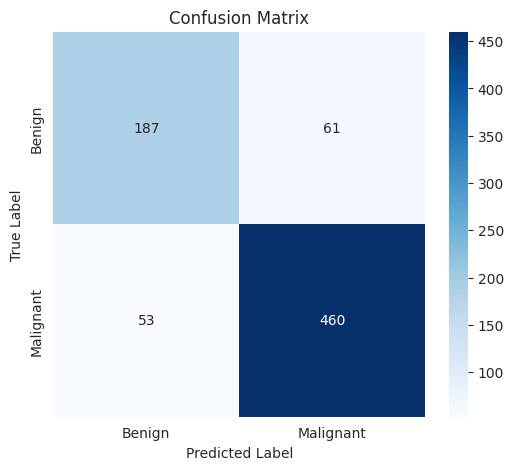

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# **Step 8: Next Step: Visualizing Model Predictions**

# **8.1 Visualizing Sample Predictions**

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


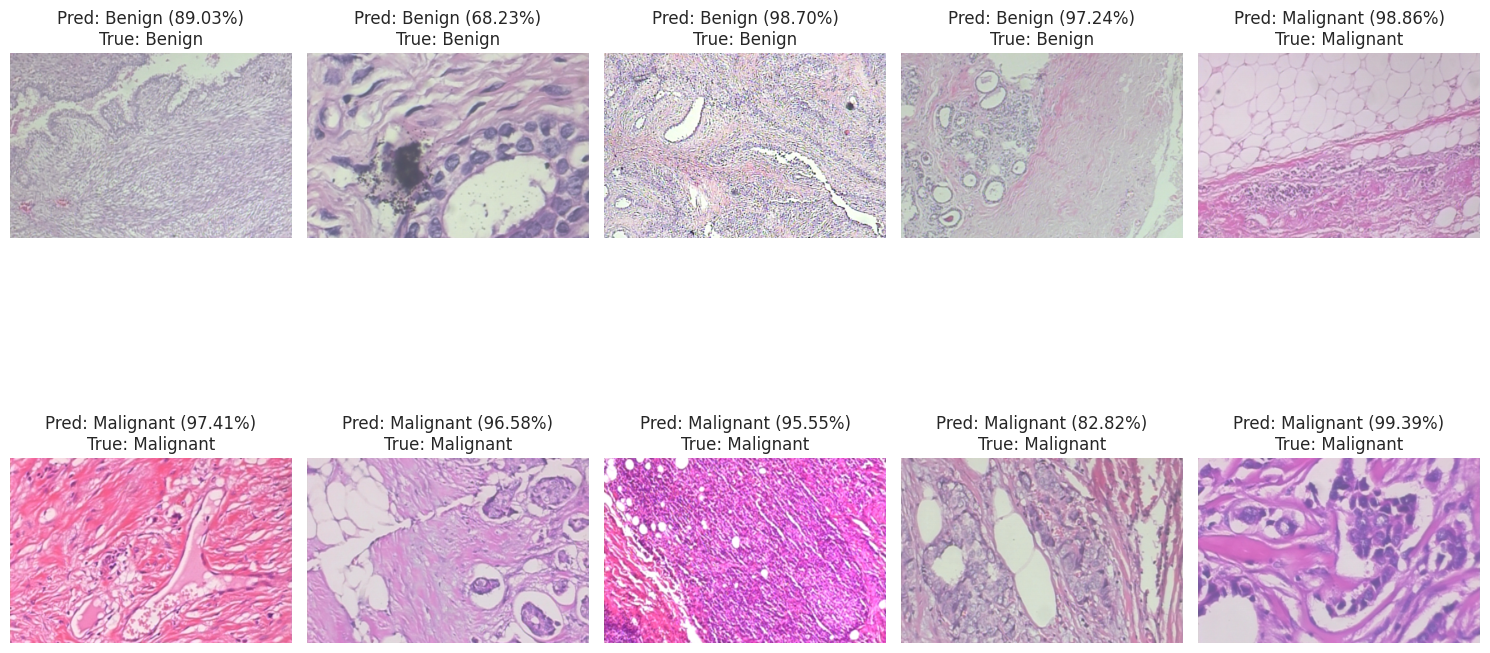

In [ ]:
import random

# Get image file paths from test set
image_files = test_generator.filenames
true_labels = test_generator.classes
class_labels = ["Benign", "Malignant"]

# Select random images for visualization
random_indices = random.sample(range(len(image_files)), 10)

# Plot images with model predictions
plt.figure(figsize=(15, 10))
for i, idx in enumerate(random_indices):
    img_path = os.path.join(test_generator.directory, image_files[idx])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Model prediction
    img_array = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img_array)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = best_model.predict(img_array)[0][0]
    predicted_label = "Malignant" if prediction > 0.5 else "Benign"
    confidence = prediction if prediction > 0.5 else 1 - prediction

    # Display image with prediction
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Pred: {predicted_label} ({confidence:.2%})\nTrue: {class_labels[true_labels[idx]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# **Improving Model Performance**

# **Data Augmentation for Better Generalization**

In [ ]:
# Define a more aggressive data augmentation strategy
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=30,  # Rotate images up to 30 degrees
    width_shift_range=0.2,  # Shift width by 20%
    height_shift_range=0.2,  # Shift height by 20%
    shear_range=0.2,  # Shear transformation
    zoom_range=0.2,  # Random zoom
    horizontal_flip=True,  # Flip images horizontally
    fill_mode="nearest"  # Fill pixels with the nearest value
)

# Apply to validation and test sets (without augmentation)
val_test_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Load training data with augmentation
train_generator = train_datagen.flow_from_dataframe(
    dataframe=data_train_balanced,
    directory=cancer_dir,
    x_col="file_loc",
    y_col="label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

# Load validation data (no augmentation)
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=data_val,
    directory=cancer_dir,
    x_col="file_loc",
    y_col="label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

# Load test data (no augmentation)
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=data_test,
    directory=cancer_dir,
    x_col="file_loc",
    y_col="label",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 8308 validated image filenames belonging to 2 classes.
Found 685 validated image filenames belonging to 2 classes.
Found 761 validated image filenames belonging to 2 classes.


# **Using Transfer Learning (ResNet50)**

# **8.3 Implementing ResNet50 for Feature Extraction**

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D, Input

# Load ResNet50 without the top layer
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=Input(shape=(224, 224, 3)))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Reduce dimensions
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)  # Prevent overfitting
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output_layer = Dense(1, activation='sigmoid')(x)  # Binary classification, get the output tensor

# Create the final model
model = Model(inputs=base_model.input, outputs=output_layer)  # Use output tensor

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)             

 Total params: 24,768,385 (94.48 MB)

 Trainable params: 1,180,673 (4.50 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

# **Training the Transfer Learning Model**

# **8.4 Train the ResNet50 Model**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define image augmentation for training data
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,
    zoom_range=0.2
)

# Validation data generator (only rescaling)
val_datagen = ImageDataGenerator(rescale=1./255)

# Test data generator (only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

# Define image size and batch size
img_size = (224, 224)
batch_size = 32

# Training generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=data_train_balanced,
    directory=cancer_dir,
    x_col="file_loc",
    y_col="class",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

# Validation generator
val_generator = val_datagen.flow_from_dataframe(
    dataframe=data_val,
    directory=cancer_dir,
    x_col="file_loc",
    y_col="class",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary"
)

# Training the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    verbose=1
)

Found 8308 validated image filenames belonging to 2 classes.
Found 685 validated image filenames belonging to 2 classes.


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_608']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


260/260 ━━━━━━━━━━━━━━━━━━━━ 268s 985ms/step - accuracy: 0.5030 - loss: 0.7639 - val_accuracy: 0.4015 - val_loss: 0.6961
Epoch 2/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 235s 903ms/step - accuracy: 0.4993 - loss: 0.6952 - val_accuracy: 0.3650 - val_loss: 0.6939
Epoch 3/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 233s 896ms/step - accuracy: 0.5061 - loss: 0.6931 - val_accuracy: 0.3299 - val_loss: 0.6949
Epoch 4/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 235s 904ms/step - accuracy: 0.4985 - loss: 0.6935 - val_accuracy: 0.4321 - val_loss: 0.6892
Epoch 5/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 263s 909ms/step - accuracy: 0.5160 - loss: 0.6904 - val_accuracy: 0.4307 - val_loss: 0.6766
Epoch 6/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 233s 895ms/step - accuracy: 0.5038 - loss: 0.6921 - val_accuracy: 0.4015 - val_loss: 0.6829
Epoch 7/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 242s 930ms/step - accuracy: 0.5216 - loss: 0.6897 - val_accuracy: 0.4015 - val_loss: 0.6862
Epoch 8/15
260/260 ━━━━━━━━━━━━━━━━━━━━ 234s 901ms/step - accuracy: 0.5047 - loss: 0.69

In [ ]:
# prompt: save the ResNet50 Model and load

# Save the model
model.save("/content/drive/MyDrive/Breast Cancer Detection using Deep Learning/Models/resnet50_model.h5")

# Load the saved model
loaded_model = load_model("/content/drive/MyDrive/Breast Cancer Detection using Deep Learning/Models/resnet50_model.h5")

# **Step 9: Model Evaluation**

# **9.1 Evaluate on Test Data**

In [ ]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_generator, verbose=1)

print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"📉 Test Loss: {test_loss:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 17s 719ms/step - accuracy: 0.4599 - loss: 0.6790
✅ Test Accuracy: 0.4494
📉 Test Loss: 0.6789


# **9.2 Classification Report & Confusion Matrix**

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_608']
Received: inputs=Tensor(shape=(32, 224, 224, 3))
  warnings.warn(msg)


24/24 ━━━━━━━━━━━━━━━━━━━━ 29s 852ms/step
              precision    recall  f1-score   support

      Benign       0.36      0.89      0.51       248
   Malignant       0.81      0.24      0.37       513

    accuracy                           0.45       761
   macro avg       0.59      0.56      0.44       761
weighted avg       0.67      0.45      0.42       761



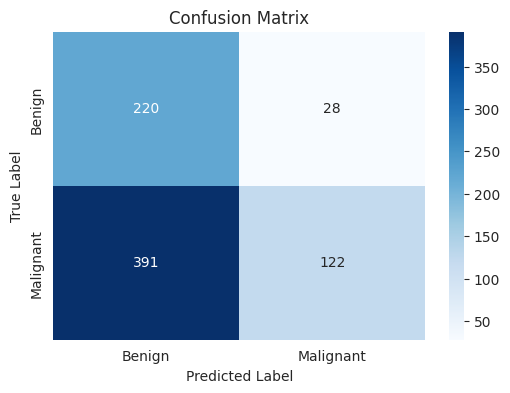

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict labels for test data
test_generator.reset()
y_pred = (model.predict(test_generator) > 0.5).astype("int32").flatten()
y_true = test_generator.classes

# Generate classification report
report = classification_report(y_true, y_pred, target_names=["Benign", "Malignant"])
print(report)

# Plot confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()